In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

In [2]:
train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

In [3]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (27455, 785)
Test Shape: (7172, 785)


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB


In [5]:
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

In [6]:
X_train.shape

(27455, 784)

In [7]:
y_train.shape

(27455,)

In [8]:
X_test.shape

(7172, 784)

In [9]:
y_test.shape

(7172,)

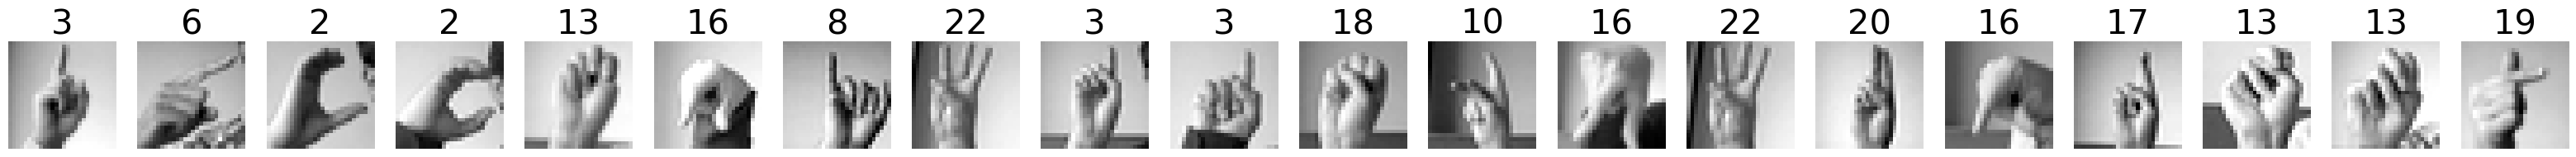

In [10]:
plt.figure(figsize=(40, 5))

num_images = 20

for i in range(num_images):
    row = X_train[i]
    label = y_train[i]

    image = row.reshape(28, 28)

    plt.subplot(1, num_images, i + 1)   
    plt.imshow(image, cmap='gray')     
    plt.title(label, fontdict={'fontsize': 30})
    plt.axis('off')


In [11]:
X_train = X_train /255
X_test  = X_test /255

In [12]:
num_classes = 25
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [13]:
y_train.shape

(27455, 25)

In [14]:
# model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Activation

In [15]:

 # input_shape = x_train.shape
model = Sequential()

# first hidden layer
model.add( Dense(units = 512, input_shape = (784,)) )
model.add(Activation('sigmoid'))

# second hidden layer
model.add(Dense(units = 512))
model.add(Activation('sigmoid'))

# output layer
model.add(Dense(units = 25) )
model.add(Activation('softmax'))

model.summary()

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │          12,825 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 25)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 677,401 (2.58 MB)

 Trainable params: 677,401 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # CHANGE THIS
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.4183 - loss: 1.8510 - val_accuracy: 0.5803 - val_loss: 1.3064
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.7225 - loss: 0.8533 - val_accuracy: 0.6432 - val_loss: 1.1128
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.8513 - loss: 0.4797 - val_accuracy: 0.7257 - val_loss: 0.8744
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9243 - loss: 0.2644 - val_accuracy: 0.7581 - val_loss: 0.8202
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9544 - loss: 0.1677 - val_accuracy: 0.7709 - val_loss: 0.7926
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - accuracy: 0.9795 - loss: 0.0895 - val_accuracy: 0.7573 - val_loss: 0.9233
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.9882 - loss: 0.0544 - val_accuracy: 0.8076 - val_loss: 0.7985
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9897 - loss: 0.0415 - 

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8090 - loss: 0.8645

Test Accuracy: 0.8089793920516968


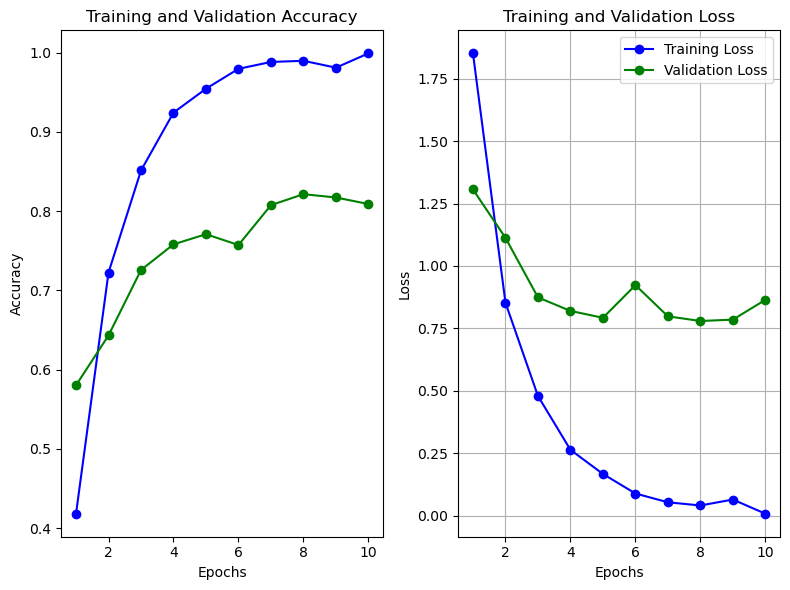

In [19]:
# Extract accuracy values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

# Plot
plt.figure(figsize=(8, 6))
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'go-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


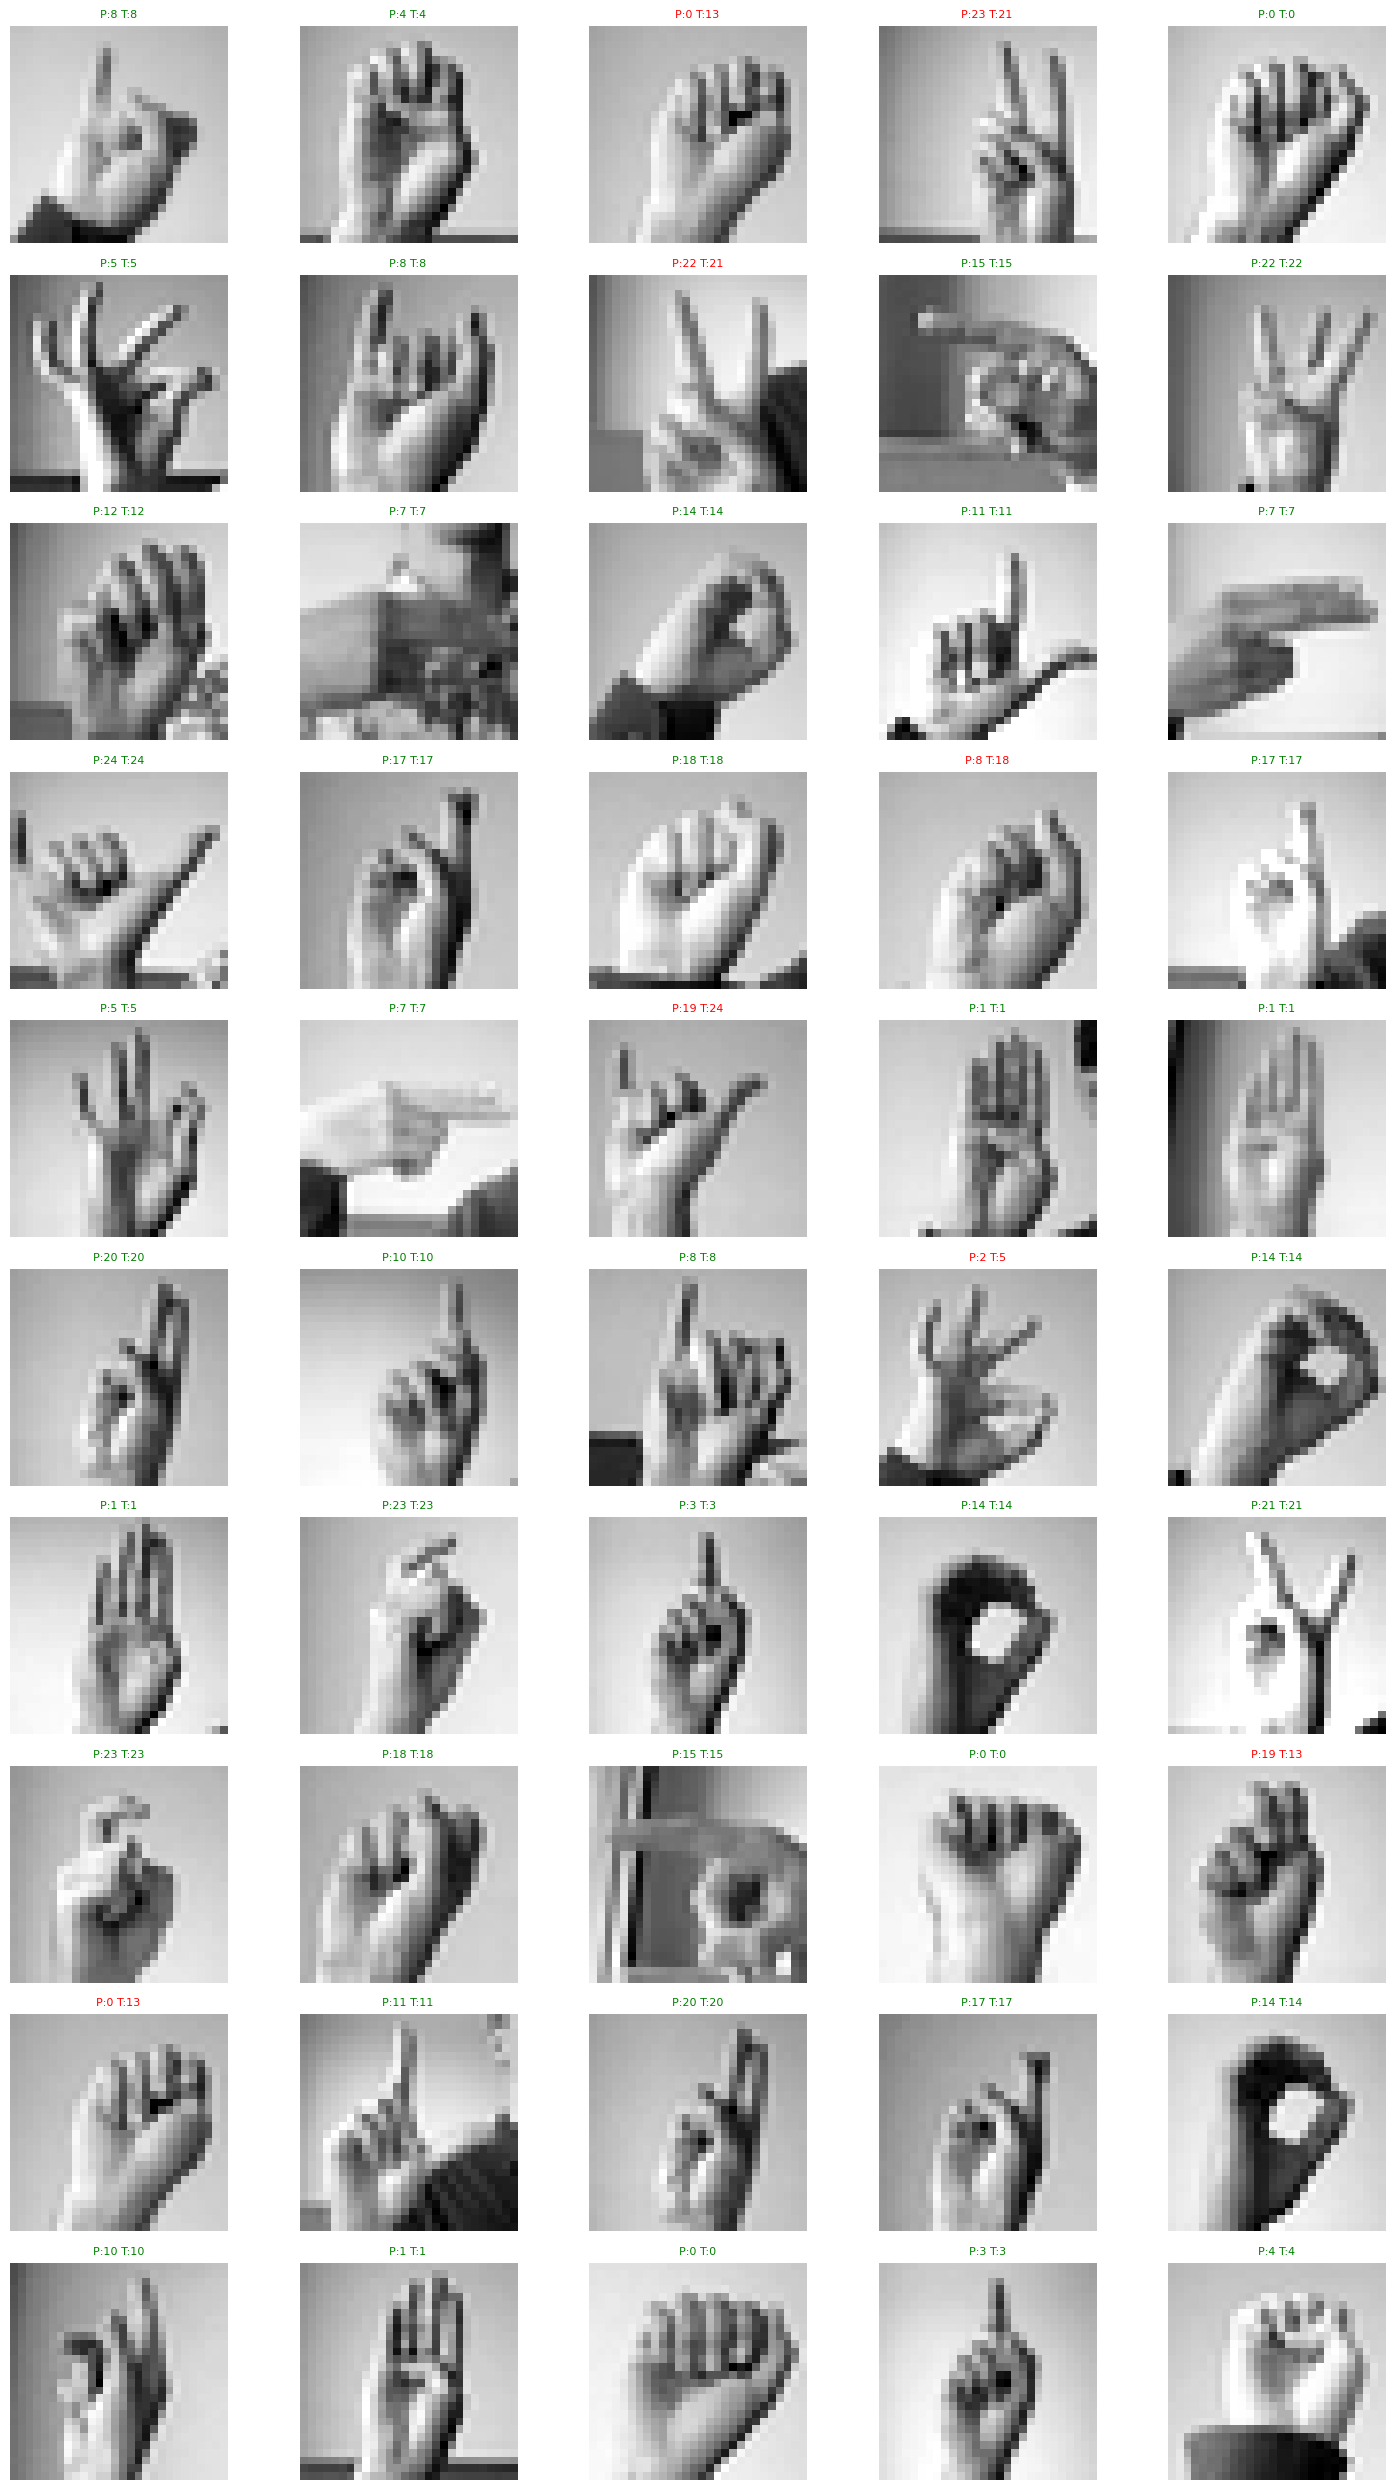

In [20]:
# Make predictions
predictions = model.predict(X_test)

num_display = 50
images_per_row = 5
rows = num_display // images_per_row

random_indices = np.random.choice(len(X_test), num_display)

plt.figure(figsize=(15, 25))

for i, idx in enumerate(random_indices):
    
    image = X_test[idx].reshape(28, 28)

    predicted_label = np.argmax(predictions[idx])
    true_label = np.argmax(y_test[idx])   # use this only if one-hot encoded

    plt.subplot(rows, images_per_row, i + 1)
    plt.imshow(image, cmap='gray')
    
    plt.title(
        f'P:{predicted_label} T:{true_label}',
        color='green' if predicted_label == true_label else 'red',
        fontsize=8
    )
    
    plt.axis('off')

plt.tight_layout()
plt.show()


In [21]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import itertools

# Define search space
learning_rates = [0.01, 0.001]
neurons = [64, 128]
batch_sizes = [32, 64]

best_accuracy = 0
best_params = None

results = []

def build_dnn(neuron, lr):
    model = Sequential([
        Dense(neuron, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(neuron//2, activation='relu'),
        Dense(y_train.shape[1], activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Grid search
for lr, n, batch in itertools.product(learning_rates, neurons, batch_sizes):
    
    print(f"\nTraining → LR:{lr} | Neurons:{n} | Batch:{batch}")
    
    model = build_dnn(n, lr)
    
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=batch,
        validation_split=0.2,
        verbose=1
    )
    
    val_acc = max(history.history['val_accuracy'])
    
    results.append((lr, n, batch, val_acc))
    
    print("Validation Accuracy:", val_acc)
    
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_params = (lr, n, batch)

# ============================================================
# Results
# ============================================================

print("\n==============================")
print("BEST PARAMETERS FOUND")
print("==============================")

print("Learning Rate:", best_params[0])
print("Neurons:", best_params[1])
print("Batch Size:", best_params[2])
print("Best Validation Accuracy:", best_accuracy)

# Optional — display all results
print("\nAll tuning results:")
for r in results:
    print(r)


Training → LR:0.01 | Neurons:64 | Batch:32


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.0438 - loss: 3.2012 - val_accuracy: 0.0479 - val_loss: 3.1797
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.0462 - loss: 3.1788 - val_accuracy: 0.0479 - val_loss: 3.1814
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0449 - loss: 3.1784 - val_accuracy: 0.0479 - val_loss: 3.1783
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0444 - loss: 3.1783 - val_accuracy: 0.0455 - val_loss: 3.1774
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.0451 - loss: 3.1780 - val_accuracy: 0.0479 - val_loss: 3.1786
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0435 - loss: 3.1779 - val_accuracy: 0.0443 - val_loss: 3.1784
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.0452 - loss: 3.1780 - val_accuracy: 0.0479 - val_loss: 3.1759
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.0429 - loss: 3.1779 - val_accuracy:

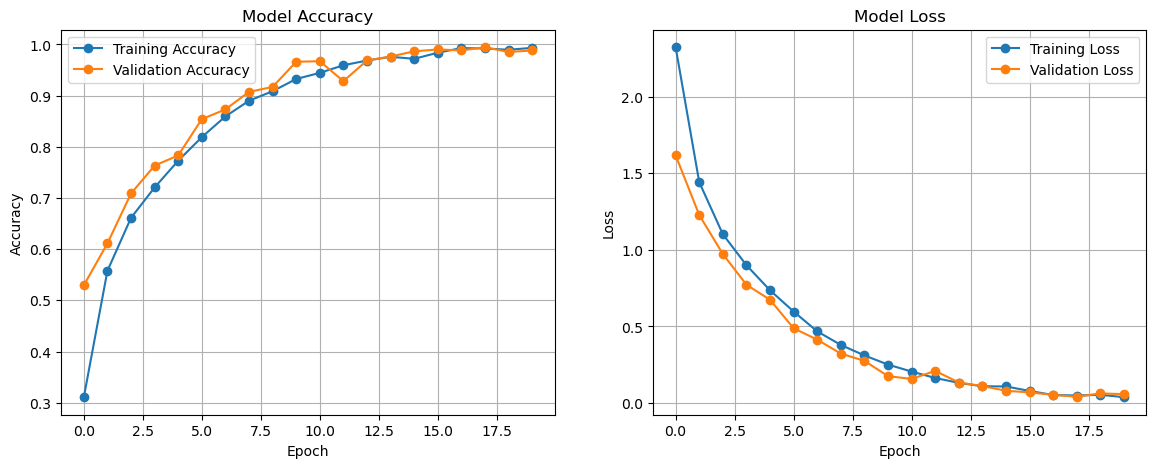

In [23]:
# ============================================================
# Training Graph — Accuracy & Loss
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()